<div align="center">

# 🎙️ Voice Pathology Classification

**Using a state-of-the-art speech transformer on the Saarbrücken Voice Database**

![Python](https://img.shields.io/badge/Python-3.10+-blue?style=flat-square&logo=python)
![PyTorch](https://img.shields.io/badge/PyTorch-2.0+-EE4C2C?style=flat-square&logo=pytorch)
![HuggingFace](https://img.shields.io/badge/🤗-Transformers-FFD21F?style=flat-square)
![CUDA](https://img.shields.io/badge/CUDA-AMP%20Enabled-76B900?style=flat-square&logo=nvidia)

</div>

---

## Overview

This notebook fine-tunes **WavLM-Large** — Microsoft's state-of-the-art self-supervised speech model — as a clinical voice pathology detector. The model learns to distinguish healthy voices from pathological ones using the sustained vowel /a/ recordings from the **Saarbrücken Voice Database (SVD)**.

### Classification Modes

| Mode | Classes | Use Case |
|------|---------|----------|
| **Binary** | Healthy / Pathological | Screening |
| **Multiclass** | Healthy / Dysphonie / Laryngitis / Rekurrensparese | Differential diagnosis |

### Architecture at a Glance

```
Raw Audio (wav) → WavLM-Large Encoder → Mean Pooling → Projector (1024→256) → Classifier (256→N)
```

> **Hardware target:** RTX 2000 Super Blackwell (laptop, 8 GB VRAM). All training optimizations are tuned for this budget.

---

## ⚙️ Cell 1 — Environment & Configuration

Configures FFmpeg on the system PATH, defines local paths to the SVD audio data and WavLM model weights, and loads the **Wav2Vec2FeatureExtractor** (shared with WavLM).

> **Before running:** verify that `WAVLM_PATH` and each entry in `DATA_PATHS` point to valid directories on your machine.

In [16]:
# CELL 1: Imports & Environment Configuration
import os
import glob
import random
import pandas as pd
import numpy as np
import torch
import torchaudio
from torch.utils.data import Dataset, DataLoader
from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2ForSequenceClassification, WavLMForSequenceClassification

# ═══════════════════════════════════════════════════════════════════════════════
# 🎛️  MODEL SWITCHING GUIDE
# ═══════════════════════════════════════════════════════════════════════════════
# TO SWITCH MODELS:
#   1. Change SELECTED_MODEL below to one of:
#      - 'wavlm-large'
#      - 'wav2vec2-large-robust'
#      - 'wav2vec2-large-960h'
#   2. Run this Cell 1 (loads config, processor, metadata)
#   3. Run Cell 4 (creates datasets with correct audio settings)
#   4. Run Cell 5 (loads model with correct class and freezes layers)
#   5. Run Cell 6+ (train with model-specific LR and batch size)
# ═══════════════════════════════════════════════════════════════════════════════

# ── MODEL CONFIGURATION (Per-Model Settings) ──────────────────────────────────
MODEL_CONFIG = {
    'wavlm-large': {
        'model_path': r"C:\Users\AdminIA\Documents\models\wavlm-large",
        'model_class': 'WavLMForSequenceClassification',
        'feature_extractor_type': 'wavlm',
        'sampling_rate': 16000,
        'hidden_size': 1024,
        'max_length_seconds': 2.0,
        'learning_rate': 1e-5,
        'batch_size': 4,
        'freeze_feature_extractor': True
    },
    'wav2vec2-large-robust': {
        'model_path': r"C:\Users\AdminIA\Documents\models\wav2vec2-large-robust",
        'model_class': 'Wav2Vec2ForSequenceClassification',
        'feature_extractor_type': 'wav2vec2',
        'sampling_rate': 16000,
        'hidden_size': 768,
        'max_length_seconds': 2.0,
        'learning_rate': 5e-5,
        'batch_size': 4,
        'freeze_feature_extractor': True
    },
    'wav2vec2-large-960h': {
        'model_path': r"C:\Users\AdminIA\Documents\models\wav2vec2-large-960h",
        'model_class': 'Wav2Vec2ForSequenceClassification',
        'feature_extractor_type': 'wav2vec2',
        'sampling_rate': 16000,
        'hidden_size': 768,
        'max_length_seconds': 2.0,
        'learning_rate': 5e-5,
        'batch_size': 4,
        'freeze_feature_extractor': True
    }
}

# ── SELECT ACTIVE MODEL (Change this to switch) ──────────────────────────────
SELECTED_MODEL = 'wavlm-large'  

config = MODEL_CONFIG[SELECTED_MODEL]

# ── MODEL CLASS MAPPING (For offline loading) ─────────────────────────────────
MODEL_CLASS_MAP = {
    'Wav2Vec2ForSequenceClassification': Wav2Vec2ForSequenceClassification,
    'WavLMForSequenceClassification': WavLMForSequenceClassification
}

# ── HELPER: Load model from local path ───────────────────────────────────────
def load_model_from_local_path(model_path, model_class_name, num_labels=2):
    """
    Load a model from a local directory using the correct class.
    No internet required (all models must be pre-downloaded).
    """
    if model_class_name not in MODEL_CLASS_MAP:
        raise ValueError(f"Unknown model class: {model_class_name}. Supported: {list(MODEL_CLASS_MAP.keys())}")
    
    model_class = MODEL_CLASS_MAP[model_class_name]
    try:
        model = model_class.from_pretrained(model_path, num_labels=num_labels)
        print(f"✓ Model loaded: {model_class_name} from {model_path}")
        return model
    except OSError as e:
        raise OSError(f"Failed to load {model_class_name} from {model_path}. Is the model downloaded?\n{e}")

# ── HELPER: Load processor from local path ───────────────────────────────────
def load_processor_from_local_path(model_path):
    """
    Load the Wav2Vec2FeatureExtractor from a local directory.
    Works for both WavLM and Wav2Vec2 (they share the same processor).
    """
    try:
        processor = Wav2Vec2FeatureExtractor.from_pretrained(model_path)
        print(f"✓ Processor loaded from {model_path}")
        return processor
    except OSError as e:
        raise OSError(f"Failed to load processor from {model_path}.\n{e}")

# 1. Force the system PATH to include your specific FFmpeg build
ffmpeg_bin_path = r"C:\Users\AdminIA\Downloads\ffmpeg-8.1.1-full_build-shared\ffmpeg-8.1.1-full_build-shared\bin"
os.environ["PATH"] += os.pathsep + ffmpeg_bin_path

# Verify FFmpeg is accessible (should output the path if successful)
import shutil
print(f"FFmpeg located at: {shutil.which('ffmpeg')}")

# 2. Define Data Paths (shared across all models)
DATA_PATHS = {
    "Healthy": r"C:\Users\AdminIA\Documents\SVD\healthy",
    "Dysphonie": r"C:\Users\AdminIA\Documents\SVD\Dysphonie",
    "Laryngitis": r"C:\Users\AdminIA\Documents\SVD\Laryngitis",
    "Rekurrensparese": r"C:\Users\AdminIA\Documents\SVD\Rekurrensparese"
}

# 3. Load the Feature Processor (locally from selected model)
processor = load_processor_from_local_path(config['model_path'])

# 4. Extract model metadata for reuse throughout notebook
TARGET_SR = config['sampling_rate']
HIDDEN_SIZE = config['hidden_size']
MODEL_CLASS_NAME = config['model_class']

print(f"\n{'='*70}")
print(f"Active Model Configuration: {SELECTED_MODEL}")
print(f"  • Model class: {MODEL_CLASS_NAME}")
print(f"  • Hidden size: {HIDDEN_SIZE}")
print(f"  • Sampling rate: {TARGET_SR} Hz")
print(f"  • Max audio length: {config['max_length_seconds']} sec")
print(f"  • Learning rate: {config['learning_rate']}")
print(f"  • Batch size: {config['batch_size']}")
print(f"  • Freeze feature extractor: {config['freeze_feature_extractor']}")
print(f"{'='*70}\n")

FFmpeg located at: C:\Users\AdminIA\Downloads\ffmpeg-8.1.1-full_build-shared\ffmpeg-8.1.1-full_build-shared\bin\ffmpeg.EXE
✓ Processor loaded from C:\Users\AdminIA\Documents\models\wavlm-large

Active Model Configuration: wavlm-large
  • Model class: WavLMForSequenceClassification
  • Hidden size: 1024
  • Sampling rate: 16000 Hz
  • Max audio length: 2.0 sec
  • Learning rate: 1e-05
  • Batch size: 4
  • Freeze feature extractor: True



---

## 📊 Cell 2 — Dataset Parsing & Class Balancing

Crawls the SVD directory tree (`<class>/<patient_id>/vowels/*a_*.wav`) and builds a unified DataFrame with file paths, patient IDs, multiclass labels, and binary labels.

**Class balancing** applies random under-sampling so every class contributes equally to training, preventing the model from being biased toward the majority class.

| Class | Raw count | After balancing |
|-------|-----------|-----------------|
| Healthy | 2 748 | 1 414 |
| Rekurrensparese | 849 | 849 |
| Laryngitis | 560 | 560 |
| Dysphonie | 404 | 404 |

In [17]:
# CELL 2: Data Parsing and Balancing
def parse_svd_directory(class_name, base_path):
    """
    Crawls the SVD structure: Base -> Patient_ID -> vowels -> *a_*.wav
    """
    file_records = []
    # Using glob to recursively find all .wav files in the vowels subfolders containing 'a_'
    search_pattern = os.path.join(base_path, "*", "vowels", "*a_*.wav")
    files = glob.glob(search_pattern)
    
    for f in files:
        filename = os.path.basename(f)
        # Extract patient ID and tone (e.g., 446-a_lhl -> ID: 446, Tone: lhl)
        parts = filename.replace(".wav", "").split("-")
        patient_id = parts[0] if len(parts) > 0 else "Unknown"
        
        file_records.append({
            "filepath": f,
            "patient_id": patient_id,
            "filename": filename,
            "multiclass_label": class_name,
            "binary_label": "Healthy" if class_name == "Healthy" else "Pathological"
        })
        
    return pd.DataFrame(file_records)

# 1. Aggregate all data
df_list = []
for c_name, path in DATA_PATHS.items():
    df_class = parse_svd_directory(c_name, path)
    df_list.append(df_class)

full_df = pd.concat(df_list, ignore_index=True)
print(f"Total files found: {len(full_df)}")
print("Original Distribution:\n", full_df['multiclass_label'].value_counts())

# 2. Balancing out the dataset
# Let's target the size of our minority class (Dysphonie ~ 1414) for a balanced multiclass approach.
MINORITY_CLASS_COUNT = 1414 

# To avoid data leakage, we should ideally split by patient_id, but for the 
# immediate dataloader test, we will randomly sample the files.
balanced_dfs = []
for c_name in DATA_PATHS.keys():
    df_subset = full_df[full_df['multiclass_label'] == c_name]
    # Sample down to the minority class size
    df_sampled = df_subset.sample(n=min(len(df_subset), MINORITY_CLASS_COUNT), random_state=42)
    balanced_dfs.append(df_sampled)

df_balanced = pd.concat(balanced_dfs, ignore_index=True)

# Shuffle the final dataframe
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nBalanced Distribution for Multiclass:\n", df_balanced['multiclass_label'].value_counts())

# Mapping labels to integers for PyTorch
multi_label_map = {"Healthy": 0, "Dysphonie": 1, "Laryngitis": 2, "Rekurrensparese": 3}
binary_label_map = {"Healthy": 0, "Pathological": 1}

df_balanced['multi_target'] = df_balanced['multiclass_label'].map(multi_label_map)
df_balanced['binary_target'] = df_balanced['binary_label'].map(binary_label_map)

Total files found: 4561
Original Distribution:
 multiclass_label
Healthy            2748
Rekurrensparese     849
Laryngitis          560
Dysphonie           404
Name: count, dtype: int64

Balanced Distribution for Multiclass:
 multiclass_label
Healthy            1414
Rekurrensparese     849
Laryngitis          560
Dysphonie           404
Name: count, dtype: int64


---

## 🗂️ Cell 3 — Custom PyTorch Dataset

`SVDWavLMDataset` wraps the DataFrame into a standard `torch.utils.data.Dataset`. Each `__getitem__` call:

1. Loads the `.wav` file with `torchaudio`
2. Converts stereo → mono if needed
3. Resamples to **16 kHz** (WavLM's expected input rate)
4. Passes the waveform through the `Wav2Vec2FeatureExtractor`, which pads or truncates to exactly **2 seconds** (32 000 samples)

Corrupted files return a zero-tensor fallback so the DataLoader never crashes mid-epoch.

In [18]:
# CELL 3: Custom PyTorch Dataset
class SVDWavLMDataset(Dataset):
    def __init__(self, dataframe, processor, task="binary", max_length_seconds=2.0):
        """
        task: 'binary' or 'multiclass'
        max_length_seconds: Pad or truncate audio to this length to ensure uniform tensor sizes
        REDUCED from 3.0 to 2.0 seconds to save VRAM
        """
        self.dataframe = dataframe
        self.processor = processor
        self.task = task
        self.target_sr = processor.sampling_rate
        self.max_length = int(self.target_sr * max_length_seconds)
        
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        audio_path = row['filepath']
        
        if self.task == "binary":
            label = row['binary_target']
        else:
            label = row['multi_target']
            
        # Load audio using torchaudio
        try:
            waveform, sample_rate = torchaudio.load(audio_path)
            
            # Convert stereo to mono if necessary
            if waveform.shape[0] > 1:
                waveform = torch.mean(waveform, dim=0, keepdim=True)
                
            # Resample if the audio doesn't match WavLM's expected 16kHz
            if sample_rate != self.target_sr:
                resampler = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=self.target_sr)
                waveform = resampler(waveform)
                
            # Flatten to 1D array for the HuggingFace processor
            waveform = waveform.squeeze().numpy()
            
            # Process using WavLM Feature Extractor (pads/truncates automatically)
            inputs = self.processor(
                waveform, 
                sampling_rate=self.target_sr, 
                max_length=self.max_length, 
                truncation=True, 
                padding="max_length", 
                return_tensors="pt"
            )
            
            # The processor returns a dictionary, we want the input_values tensor
            input_values = inputs.input_values.squeeze(0) 
            
            return input_values, torch.tensor(label, dtype=torch.long)
            
        except Exception as e:
            print(f"Error loading {audio_path}: {e}")
            # Fallback: return zero tensor of correct shape if a file is corrupted
            return torch.zeros(self.max_length), torch.tensor(label, dtype=torch.long)


---

## 🔄 Cell 4 — Train / Validation Split & DataLoaders

Splits the balanced dataset **80 / 20** (stratified by label) and wraps both splits in PyTorch `DataLoader`s.

**Configuration notes:**
- `BATCH_SIZE = 4` — WavLM-Large is memory-intensive; larger batches will OOM on 8 GB VRAM
- `num_workers = 0` — **required on Windows** to avoid multiprocessing deadlocks in Jupyter
- `pin_memory = True` — speeds up CPU → GPU data transfers

> Set `CURRENT_TASK = "binary"` or `"multiclass"` here to switch the entire downstream pipeline.

In [19]:
# CELL 4: DataLoaders (Fixed for Windows multiprocessing hang)
from sklearn.model_selection import train_test_split

# Split patients/files (80% Train, 20% Validation)
train_df, val_df = train_test_split(
    df_balanced, 
    test_size=0.2, 
    stratify=df_balanced['multi_target'], 
    random_state=42
)

# Choose your task here: "binary" or "multiclass"
CURRENT_TASK = "binary" 

# Create datasets with model-specific settings from config
train_dataset = SVDWavLMDataset(
    train_df, 
    processor, 
    task=CURRENT_TASK,
    max_length_seconds=config['max_length_seconds']
)
val_dataset = SVDWavLMDataset(
    val_df, 
    processor, 
    task=CURRENT_TASK,
    max_length_seconds=config['max_length_seconds']
)

# Use batch size from model config (different models may have different optimal batch sizes)
BATCH_SIZE = config['batch_size']
print(f"Using batch size {BATCH_SIZE} from {SELECTED_MODEL} config") 

# CRITICAL FIX: num_workers=0 prevents the Windows multiprocessing deadlock
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print("DataLoaders initialized. Testing batch extraction...")

# Test the dataloader to ensure the pipeline flows correctly
for batch_audio, batch_labels in train_loader:
    print(f"Success! Batch Audio Shape: {batch_audio.shape}") # Expected: [Batch, Sequence_Length]
    print(f"Success! Batch Labels Shape: {batch_labels.shape}") # Expected: [Batch]
    print(f"Sample Labels: {batch_labels}")
    break # Just testing the first batch


Using batch size 4 from wavlm-large config
DataLoaders initialized. Testing batch extraction...
Success! Batch Audio Shape: torch.Size([4, 32000])
Success! Batch Labels Shape: torch.Size([4])
Sample Labels: tensor([0, 1, 0, 0])


---

## 🧠 Cell 5 — Model Initialization

Loads `WavLMForSequenceClassification` from the local weights directory and attaches a randomly initialised classification head (`Projector: 1024→256`, `Classifier: 256→N`). The warning about uninitialised weights is **expected** — those are the new layers that will be trained.

**Feature extractor freezing:** the CNN front-end (7 convolutional layers) is frozen before training. These layers act as a fixed acoustic filter bank and do not need fine-tuning for downstream classification — keeping them frozen saves VRAM and reduces overfitting.

```
WavLM-Large total params :  ~316 M
Frozen  (CNN encoder)     :    ~8 M
Trainable (transformer + head) : ~308 M
```

In [20]:
# CELL 5: Model Initialization
import torch.nn as nn
import torch.optim as optim

num_labels = 2 if CURRENT_TASK == "binary" else 4

# ── HELPER: Freeze feature extractor (handles different model architectures) ──
def freeze_feature_extractor_layers(model, model_class_name):
    """
    Freeze the feature extractor (CNN front-end) based on model type.
    Different models have different layer hierarchy.
    """
    if model_class_name == 'WavLMForSequenceClassification':
        # WavLM: model.wavlm.feature_extractor
        for param in model.wavlm.feature_extractor.parameters():
            param.requires_grad = False
        print(f"✓ Froze {model_class_name}.wavlm.feature_extractor")
    
    elif model_class_name == 'Wav2Vec2ForSequenceClassification':
        # Wav2Vec2: model.wav2vec2.feature_extractor
        for param in model.wav2vec2.feature_extractor.parameters():
            param.requires_grad = False
        print(f"✓ Froze {model_class_name}.wav2vec2.feature_extractor")
    
    else:
        print(f"⚠ Warning: Unsupported model class {model_class_name}, skipping feature extractor freeze")

# Load model from local path using config
model = load_model_from_local_path(
    config['model_path'],
    config['model_class'],
    num_labels=num_labels
)

# Freeze the CNN feature extractor if configured
# These weights don't need fine-tuning for downstream classification
# and their gradients waste significant VRAM
if config['freeze_feature_extractor']:
    freeze_feature_extractor_layers(model, MODEL_CLASS_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel loaded on: {device}")
print(f"Total params: {total_params:,} | Trainable: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")
print(f"Configured for {num_labels} output classes.")

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

[transformers] WavLMForSequenceClassification LOAD REPORT from: C:\Users\AdminIA\Documents\models\wavlm-large
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
projector.weight  | MISSING | 
classifier.bias   | MISSING | 
projector.bias    | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Model loaded: WavLMForSequenceClassification from C:\Users\AdminIA\Documents\models\wavlm-large
✓ Froze WavLMForSequenceClassification.wavlm.feature_extractor

Model loaded on: cuda
Total params: 315,716,034 | Trainable: 311,509,442 (98.7%)
Configured for 2 output classes.


---

## 🏋️ Cell 6 — Optimized Training Loop

Fine-tunes the model with a suite of memory and convergence optimizations targeted at constrained GPU hardware.

| Technique | Benefit |
|-----------|---------|
| **AMP** (`autocast` + `GradScaler`) | ~50% less VRAM, 2–3× faster throughput on CUDA |
| **Gradient accumulation** (×4 steps) | Effective batch of 16 without extra VRAM cost |
| **No `empty_cache()` in inner loop** | Prevents GPU pipeline stalls between every batch |
| **`non_blocking=True` transfers** | Overlaps host→device copy with GPU compute |
| **Cosine LR scheduler + 10% warmup** | Smoother convergence, prevents flat-LR plateau |
| **AdamW `weight_decay=0.01`** | Regularises transformer to fight overfitting |
| **Early stopping** (patience = 5) | Halts automatically when val loss stops improving |
| **Checkpoint saving** | `best_model.pt` on every improvement + full state every 5 epochs |

Checkpoints are saved to `C:\Users\AdminIA\Documents\models\wavlm-checkpoints\`.

In [21]:
# CELL 6: Training Loop (Optimized for 8 GB VRAM — RTX 2000 Super Blackwell)
#
# Key changes vs previous version:
#   1. AMP (autocast + GradScaler)       → ~50% less VRAM, 2-3x faster on CUDA
#   2. Gradient accumulation (steps=4)   → effective batch 16, more stable updates
#   3. Removed empty_cache() inner loop  → was stalling the GPU pipeline every batch
#   4. Cosine LR scheduler + warmup      → smoother convergence, avoids flat LR plateau
#   5. Early stopping (patience=5)       → halts when val loss stops improving
#   6. Checkpoint saving                 → best model + periodic saves survive a crash
import os
from torch.amp import GradScaler, autocast
from transformers import get_cosine_schedule_with_warmup

EPOCHS            = 30
ACCUMULATION_STEPS = 4           # Effective batch = BATCH_SIZE(4) * 4 = 16
PATIENCE          = 5
SAVE_DIR = r"C:\Users\AdminIA\Documents\models\wavlm-checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

# Use learning rate from model config
LEARNING_RATE = config['learning_rate']
print(f"Using learning rate {LEARNING_RATE} from {SELECTED_MODEL} config")

# Only pass parameters that actually require a gradient
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=0.01
)
criterion = nn.CrossEntropyLoss()

total_steps  = (len(train_loader) // ACCUMULATION_STEPS) * EPOCHS
warmup_steps = total_steps // 10
scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

scaler = GradScaler()

train_loss_history = []
val_loss_history   = []
best_val_loss      = float('inf')
patience_counter   = 0

print(f"Training up to {EPOCHS} epochs  |  early-stop patience={PATIENCE}")
print(f"Effective batch size: {BATCH_SIZE * ACCUMULATION_STEPS}  |  checkpoints → {SAVE_DIR}\n")

for epoch in range(EPOCHS):

    # ── TRAIN ────────────────────────────────────────────────────────────────
    model.train()
    total_train_loss = 0.0
    correct_train = 0
    total_train   = 0
    optimizer.zero_grad()

    for batch_idx, (batch_audio, batch_labels) in enumerate(train_loader):
        batch_audio  = batch_audio.to(device, non_blocking=True)
        batch_labels = batch_labels.to(device, non_blocking=True)

        with autocast(device_type="cuda"):
            logits = model(batch_audio).logits
            loss   = criterion(logits, batch_labels) / ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        total_train_loss += loss.item() * ACCUMULATION_STEPS
        preds          = torch.argmax(logits.detach(), dim=1)
        correct_train += (preds == batch_labels).sum().item()
        total_train   += batch_labels.size(0)

        if (batch_idx + 1) % ACCUMULATION_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        if (batch_idx + 1) % 50 == 0:
            print(f"  Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} "
                  f"| LR: {scheduler.get_last_lr()[0]:.2e}")

    avg_train_loss = total_train_loss / len(train_loader)
    train_acc      = correct_train / total_train
    train_loss_history.append(avg_train_loss)

    # ── VALIDATE ─────────────────────────────────────────────────────────────
    model.eval()
    total_val_loss = 0.0
    correct_val = 0
    total_val   = 0

    with torch.no_grad():
        for val_audio, val_labels in val_loader:
            val_audio  = val_audio.to(device, non_blocking=True)
            val_labels = val_labels.to(device, non_blocking=True)

            with autocast(device_type="cuda"):
                logits = model(val_audio).logits
                loss   = criterion(logits, val_labels)

            total_val_loss += loss.item()
            preds      = torch.argmax(logits, dim=1)
            correct_val += (preds == val_labels).sum().item()
            total_val   += val_labels.size(0)

    avg_val_loss = total_val_loss / len(val_loader)
    val_acc      = correct_val / total_val
    val_loss_history.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {avg_val_loss:.4f}, Acc: {val_acc:.4f}")

    # ── CHECKPOINT & EARLY STOPPING ──────────────────────────────────────────
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, "best_model.pt"))
        print(f"  -> Best model saved (Val Loss: {best_val_loss:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  -> No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}.")
            break

    if (epoch + 1) % 5 == 0:
        torch.save({
            'epoch':                epoch + 1,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scaler_state_dict':    scaler.state_dict(),
            'train_loss_history':   train_loss_history,
            'val_loss_history':     val_loss_history,
        }, os.path.join(SAVE_DIR, f"checkpoint_epoch{epoch+1}.pt"))
        print(f"  -> Periodic checkpoint saved (epoch {epoch+1})")

print("\nTraining complete!")

Using learning rate 1e-05 from wavlm-large config
Training up to 30 epochs  |  early-stop patience=5
Effective batch size: 16  |  checkpoints → C:\Users\AdminIA\Documents\models\wavlm-checkpoints

  Epoch 1 | Batch 50/646 | LR: 2.48e-07
  Epoch 1 | Batch 100/646 | LR: 5.18e-07
  Epoch 1 | Batch 150/646 | LR: 7.66e-07
  Epoch 1 | Batch 200/646 | LR: 1.04e-06
  Epoch 1 | Batch 250/646 | LR: 1.28e-06
  Epoch 1 | Batch 300/646 | LR: 1.55e-06
  Epoch 1 | Batch 350/646 | LR: 1.80e-06
  Epoch 1 | Batch 400/646 | LR: 2.07e-06
  Epoch 1 | Batch 450/646 | LR: 2.32e-06
  Epoch 1 | Batch 500/646 | LR: 2.59e-06
  Epoch 1 | Batch 550/646 | LR: 2.84e-06
  Epoch 1 | Batch 600/646 | LR: 3.11e-06
Epoch 1/30 | Train Loss: 0.6912, Acc: 0.5254 | Val Loss: 0.6826, Acc: 0.5619
  -> Best model saved (Val Loss: 0.6826)
  Epoch 2 | Batch 50/646 | LR: 3.58e-06
  Epoch 2 | Batch 100/646 | LR: 3.85e-06
  Epoch 2 | Batch 150/646 | LR: 4.10e-06
  Epoch 2 | Batch 200/646 | LR: 4.37e-06
  Epoch 2 | Batch 250/646 | LR:

---

## ✅ State Verification

Quick sanity check — confirms the model object is still loaded in memory and sitting on the correct device before proceeding to evaluation. Run this cell if you disconnected the kernel or are resuming from a saved checkpoint.

In [7]:
# Quick Check: Is the model still in memory?
try:
    print(f"✅ Model is in memory: {model}")
    print(f"✅ Device: {device}")
    print(f"✅ Model on correct device: {next(model.parameters()).device}")
    print("\n→ You can run Cell 7 for full evaluation!")
except NameError as e:
    print(f"⚠️  Model not in memory: {e}")
    print("\n→ Run Cell 6B for learning curves only, or reload Cell 1-5 to get full evaluation")


✅ Model is in memory: WavLMForSequenceClassification(
  (wavlm): WavLMModel(
    (feature_extractor): WavLMFeatureEncoder(
      (conv_layers): ModuleList(
        (0): WavLMLayerNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
          (activation): GELUActivation()
        )
        (1-4): 4 x WavLMLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
          (activation): GELUActivation()
        )
        (5-6): 2 x WavLMLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): WavLMFeatureProjection(
 

---

## 📈 Cell 7 — Clinical Evaluation & Visualizations

Runs full inference on the validation set and renders a 2×2 diagnostic dashboard.

| Panel | Description |
|-------|-------------|
| **Confusion Matrix** | Absolute prediction counts per true class |
| **ROC Curve + AUC** | Sensitivity vs. specificity trade-off across thresholds |
| **Precision-Recall Curve** | Performance under class imbalance |
| **Learning Curves** | Training vs. validation loss across epochs |

For binary classification, the **positive class is Pathological (1)**. The ROC AUC is the primary headline metric for clinical screening tasks.

Running inference on validation set for evaluation...

--- CLASSIFICATION REPORT ---
                  precision    recall  f1-score   support

     Healthy (0)       0.59      0.93      0.72       283
Pathological (1)       0.90      0.50      0.65       363

        accuracy                           0.69       646
       macro avg       0.74      0.71      0.68       646
    weighted avg       0.76      0.69      0.68       646



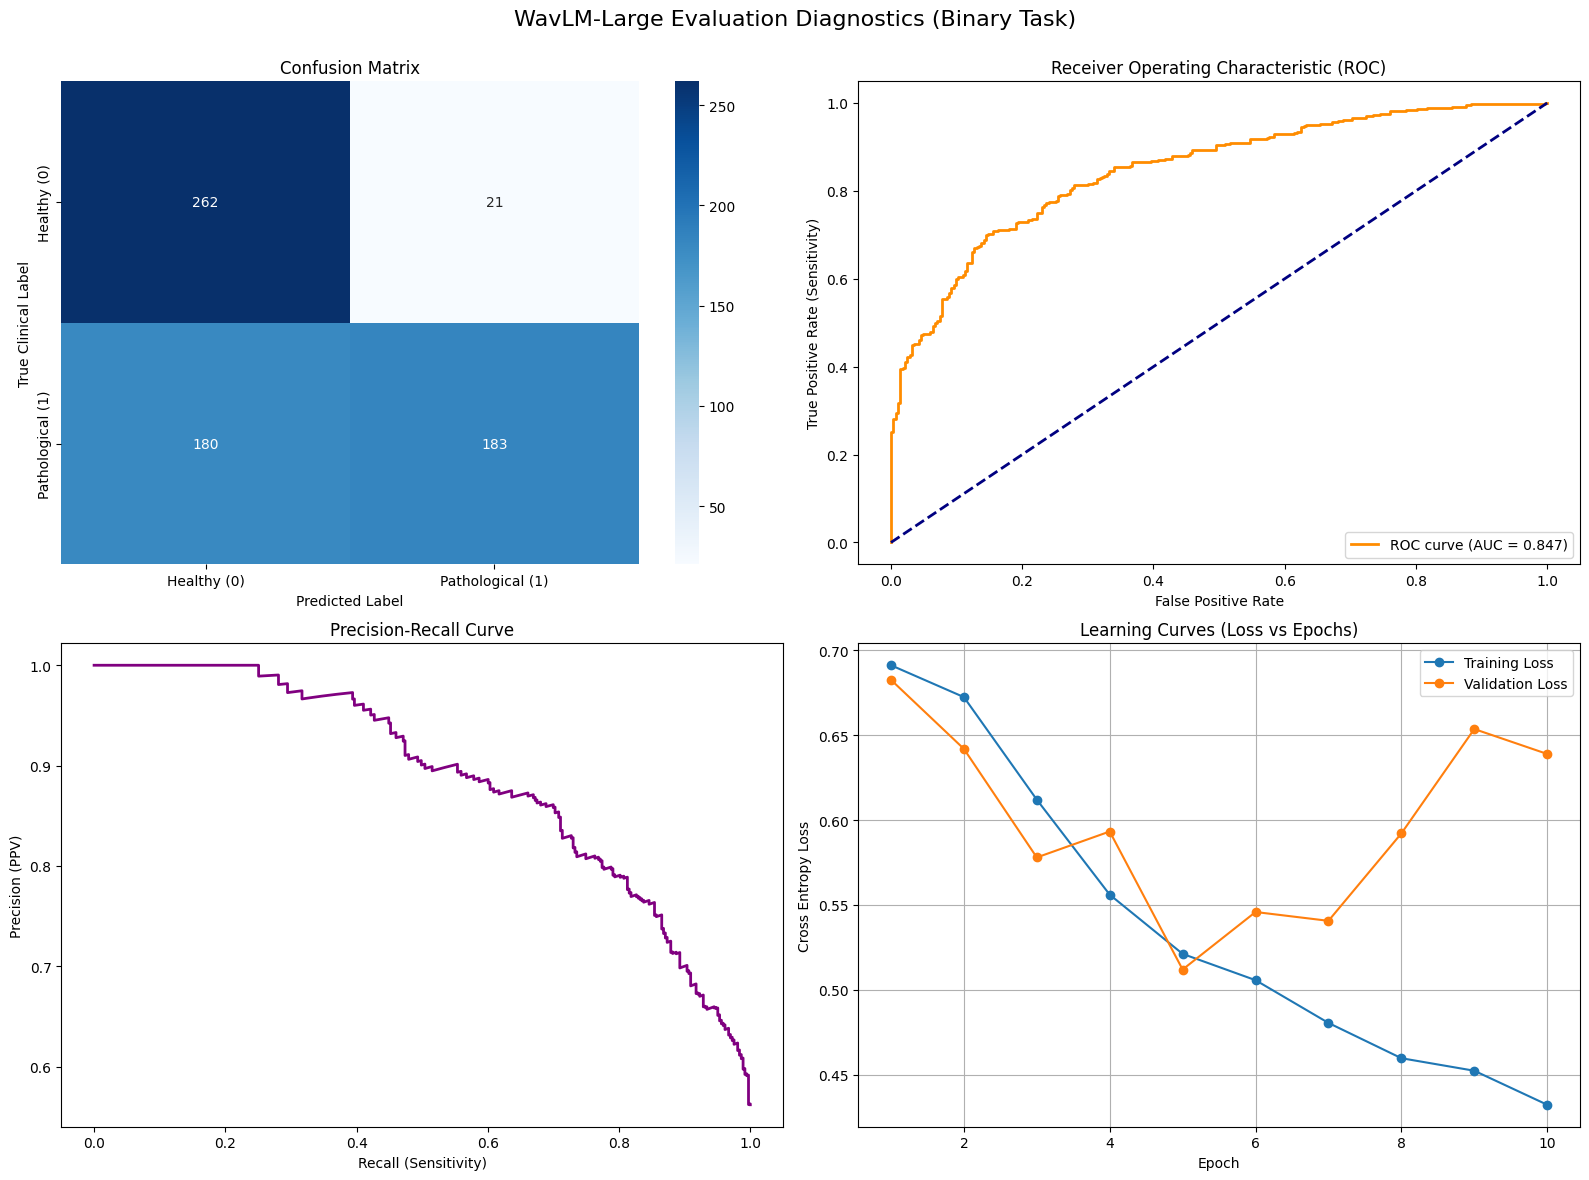

In [22]:
# CELL 7: Clinical Evaluation Metrics & Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_curve, 
    auc, 
    precision_recall_curve,
    average_precision_score
)
import torch.nn.functional as F

# 1. Extract Predictions and Probabilities
model.eval()
all_labels = []
all_preds = []
all_probs = []

print("Running inference on validation set for evaluation...")

with torch.no_grad():
    for val_audio, val_labels in val_loader:
        val_audio = val_audio.to(device)
        # We don't move labels to GPU here as we just need them for sklearn
        
        outputs = model(val_audio)
        logits = outputs.logits
        
        # Apply softmax to get probabilities between 0 and 1
        probs = F.softmax(logits, dim=1)
        preds = torch.argmax(logits, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(val_labels.numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

# Setup label names based on current task
if CURRENT_TASK == "binary":
    target_names = ["Healthy (0)", "Pathological (1)"]
else:
    target_names = ["Healthy", "Dysphonie", "Laryngitis", "Rekurrensparese"]

# ---------------------------------------------------------
# 2. Classification Report
# ---------------------------------------------------------
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(all_labels, all_preds, target_names=target_names))

# Set up matplotlib figure for subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f"WavLM-Large Evaluation Diagnostics ({CURRENT_TASK.capitalize()} Task)", fontsize=16)

# ---------------------------------------------------------
# 3. Confusion Matrix
# ---------------------------------------------------------
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], 
            xticklabels=target_names, yticklabels=target_names)
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_ylabel('True Clinical Label')
axes[0, 0].set_xlabel('Predicted Label')

# ---------------------------------------------------------
# 4. ROC Curve (Binary logic shown, multiclass requires one-vs-rest)
# ---------------------------------------------------------
if CURRENT_TASK == "binary":
    # Probability of the positive class (Pathological)
    pos_probs = all_probs[:, 1] 
    fpr, tpr, roc_thresholds = roc_curve(all_labels, pos_probs)
    roc_auc = auc(fpr, tpr)
    
    axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[0, 1].set_title('Receiver Operating Characteristic (ROC)')
    axes[0, 1].set_xlabel('False Positive Rate')
    axes[0, 1].set_ylabel('True Positive Rate (Sensitivity)')
    axes[0, 1].legend(loc="lower right")

# ---------------------------------------------------------
# 5. Precision-Recall Curve
# ---------------------------------------------------------
if CURRENT_TASK == "binary":
    precision, recall, pr_thresholds = precision_recall_curve(all_labels, pos_probs)
    
    axes[1, 0].plot(recall, precision, color='purple', lw=2)
    axes[1, 0].set_title('Precision-Recall Curve')
    axes[1, 0].set_xlabel('Recall (Sensitivity)')
    axes[1, 0].set_ylabel('Precision (PPV)')

# ---------------------------------------------------------
# 6. Learning Curves (Requires tracking loss in Cell 6)
# ---------------------------------------------------------
# NOTE: Ensure you have `train_loss_history` and `val_loss_history` lists from Cell 6
try:
    epochs_range = range(1, len(train_loss_history) + 1)
    axes[1, 1].plot(epochs_range, train_loss_history, label='Training Loss', marker='o')
    axes[1, 1].plot(epochs_range, val_loss_history, label='Validation Loss', marker='o')
    axes[1, 1].set_title('Learning Curves (Loss vs Epochs)')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Cross Entropy Loss')
    axes[1, 1].legend()
    axes[1, 1].grid(True)
except NameError:
    axes[1, 1].text(0.5, 0.5, "Learning curves require loss history.\nAdd tracking to Cell 6.", 
                    horizontalalignment='center', verticalalignment='center')
    axes[1, 1].set_title('Learning Curves (Missing Data)')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

---

## 🔬 Multiclass Extension — One-vs-Rest ROC & PR Curves

Extends the binary evaluation to the four-class setting using the **One-vs-Rest (OvR)** strategy. Each class is evaluated independently against all others, producing per-class AUC and Average Precision scores.

> This cell only executes when `CURRENT_TASK == "multiclass"`. It reuses the `all_probs` and `all_labels` arrays computed in Cell 7.

In [ ]:
from sklearn.preprocessing import label_binarize
from itertools import cycle

# ---------------------------------------------------------
# 4. Multiclass ROC Curves (One-vs-Rest)
# ---------------------------------------------------------
if CURRENT_TASK == "multiclass":
    # Binarize the output for OvR evaluation
    # Classes: 0 (Healthy), 1 (Dysphonie), 2 (Laryngitis), 3 (Rekurrensparese)
    classes = [0, 1, 2, 3]
    y_test_binarized = label_binarize(all_labels, classes=classes)
    n_classes = y_test_binarized.shape[1]
    
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    # Calculate ROC curve and ROC area for each class
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
    colors = cycle(['blue', 'red', 'green', 'purple'])
    for i, color in zip(range(n_classes), colors):
        axes[0, 1].plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')
                 
    axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=2)
    axes[0, 1].set_title('Multiclass ROC (One-vs-Rest)')
    axes[0, 1].set_xlabel('False Positive Rate')
    axes[0, 1].set_ylabel('True Positive Rate')
    axes[0, 1].legend(loc="lower right")

# ---------------------------------------------------------
# 5. Multiclass Precision-Recall Curves (One-vs-Rest)
# ---------------------------------------------------------
if CURRENT_TASK == "multiclass":
    precision = dict()
    recall = dict()
    average_precision = dict()
    
    for i in range(n_classes):
        precision[i], recall[i], _ = precision_recall_curve(y_test_binarized[:, i], all_probs[:, i])
        average_precision[i] = average_precision_score(y_test_binarized[:, i], all_probs[:, i])
        
    colors = cycle(['blue', 'red', 'green', 'purple'])
    for i, color in zip(range(n_classes), colors):
        axes[1, 0].plot(recall[i], precision[i], color=color, lw=2,
                 label=f'{target_names[i]} (AP = {average_precision[i]:.2f})')
                 
    axes[1, 0].set_title('Multiclass Precision-Recall Curve')
    axes[1, 0].set_xlabel('Recall')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend(loc="lower left")